In [1]:
from nmmlab.ho import ho, forced_dho, resonance_curve, coupled_dho, euler_maruyama, kuramoto
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#PARAMETERS 
# time
t = np.arange(0, 10, 0.01)
omega_forced = 2 * np.pi * 1  # 1 Hz
t_forced = np.linspace(0, 60, 3000)

# single oscillator
omega = 2 * np.pi * 10
alpha = -0.1
F0 = 1.0
z0 = 1 + 0j

# network
N = 3
alphas = np.ones(N) * -0.1
omegas = np.linspace(0.5, 2.0, N)
C = np.random.rand(N, N)
np.fill_diagonal(C, 0)
rng = np.random.default_rng(42)
z0_net = np.exp(1j * rng.uniform(0, 2*np.pi, N))
F_net = np.zeros(N)

# Kuramoto
N_k = 50
rng_k = np.random.default_rng(42)
omegas_k = rng_k.uniform(0.9, 1.1, N_k) * 2 * np.pi
f_max = omegas_k.max() / (2 * np.pi)
dt_k = 1 / (50 * f_max)
t_k = np.arange(0, 30, dt_k)
G_values = np.linspace(0, 1.0, 40)

alpha_damp = -0.3          # damping (negative = decay)
omega_damp = 2 * np.pi * 1.0
t_damp = np.linspace(0, 10, 1000)
z0_damp = 1 + 0j

z_damp = z0_damp * np.exp((1j * omega_damp + alpha_damp) * t_damp)

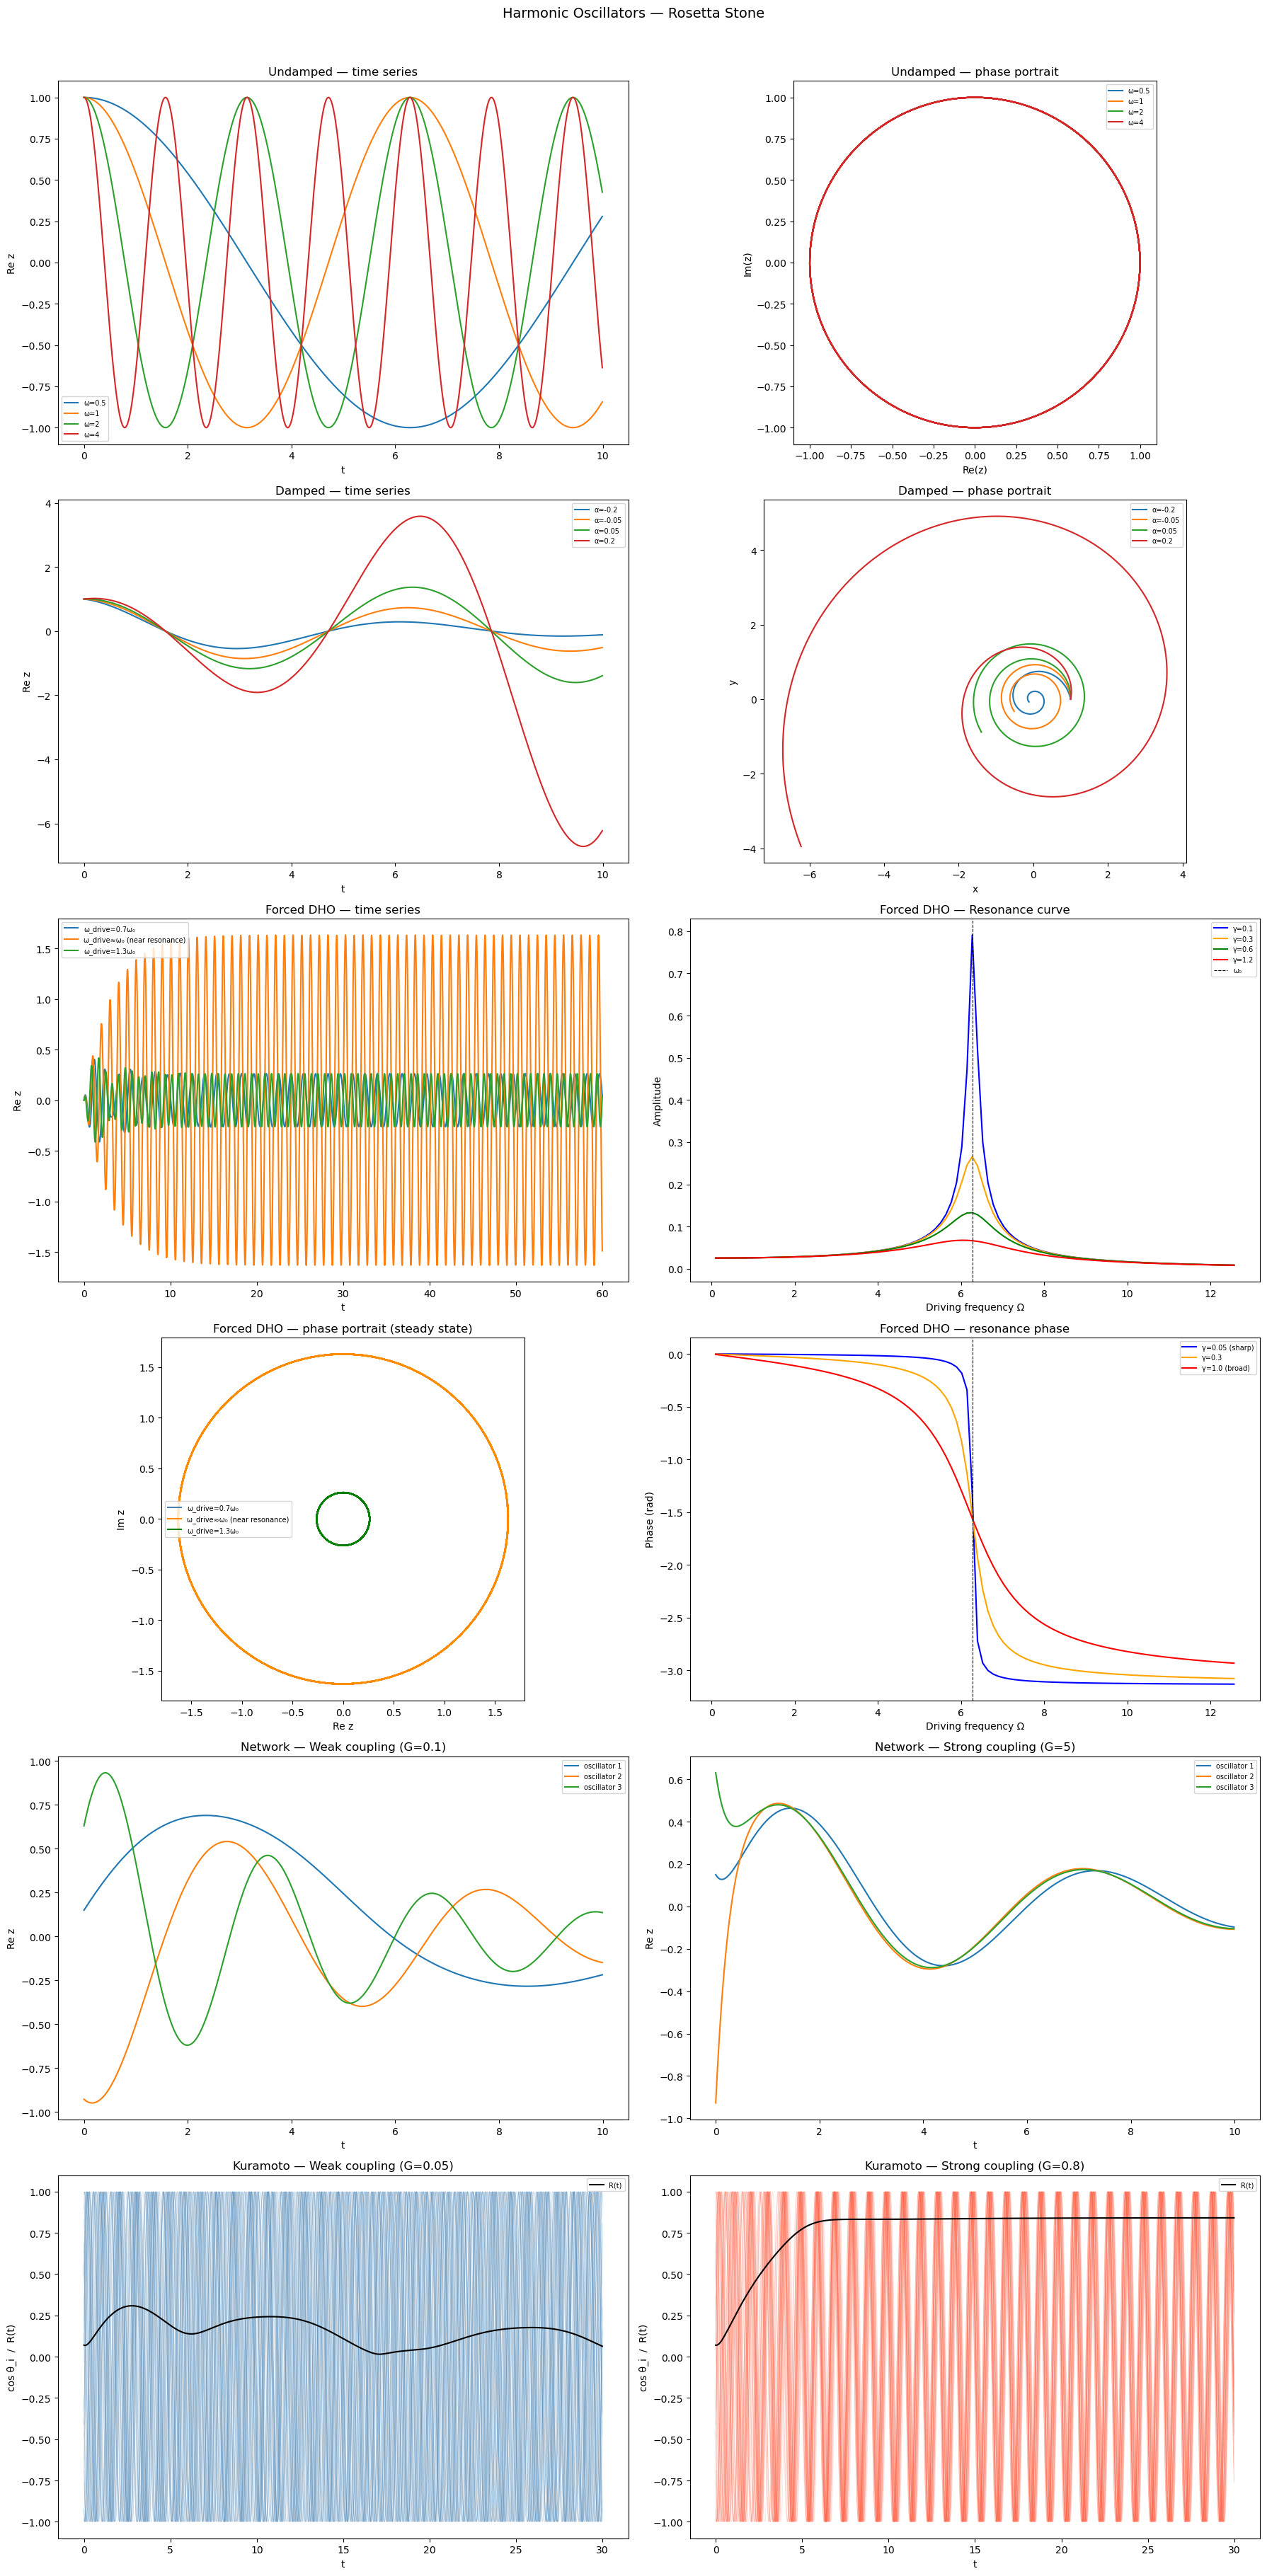

In [3]:
fig = plt.figure(figsize=(18, 36))

# ── Row 1: Undamped HO ──
ax1 = fig.add_subplot(6, 2, 1)
ax2 = fig.add_subplot(6, 2, 2)
for omega_val in [0.5, 1, 2, 4]:
    z = ho(omega=omega_val, alpha=0, z0=1+0j, t=t)
    ax1.plot(t, z.real, label=f"ω={omega_val}")
    ax2.plot(z.real, z.imag, label=f"ω={omega_val}")
ax1.set_title("Undamped — time series")
ax1.set_xlabel("t"); ax1.set_ylabel("Re z")
ax2.set_title("Undamped — phase portrait")
ax2.set_xlabel("Re(z)"); ax2.set_ylabel("Im(z)")
ax2.set_aspect("equal")
ax1.legend(fontsize=7); ax2.legend(fontsize=7)

# ── Row 2: Damped HO ──
ax3 = fig.add_subplot(6, 2, 3)
ax4 = fig.add_subplot(6, 2, 4)
for alpha_val in [-0.2, -0.05, 0.05, 0.2]:
    z = ho(omega=1, alpha=alpha_val, z0=1+0j, t=t)
    ax3.plot(t, z.real, label=f"α={alpha_val}")
    ax4.plot(z.real, z.imag, label=f"α={alpha_val}")
ax3.set_title("Damped — time series")
ax3.set_xlabel("t"); ax3.set_ylabel("Re z")
ax4.set_title("Damped — phase portrait")
ax4.set_xlabel("x"); ax4.set_ylabel("y")
ax4.set_aspect("equal")
ax3.legend(fontsize=7); ax4.legend(fontsize=7)

# ── Row 3: Forced DHO — time series + resonance curve ──
ax5 = fig.add_subplot(6, 2, 5)
ax6 = fig.add_subplot(6, 2, 6)
t_forced = np.linspace(0, 60, 3000)
drives = [omega_forced * 0.7, omega_forced * 0.99, omega_forced * 1.3]
labels_f = ['ω_drive=0.7ω₀', 'ω_drive≈ω₀ (near resonance)', 'ω_drive=1.3ω₀']
for od, lab in zip(drives, labels_f):
    z = forced_dho(omega=omega_forced, alpha=-0.3, F0=0.5, omega_drive=od, z0=0+0j, t=t_forced)
    ax5.plot(t_forced, z.real, label=lab)
ax5.set_title("Forced DHO — time series")
ax5.set_xlabel("t"); ax5.set_ylabel("Re z")
ax5.legend(fontsize=7)
omega_drives_low = np.linspace(0.1, 4 * np.pi, 100)
for gamma, col, lab in zip([0.1, 0.3, 0.6, 1.2], ['blue', 'orange', 'green', 'red'],
                            ['γ=0.1', 'γ=0.3', 'γ=0.6', 'γ=1.2']):
    H_g = 1.0 / (omega_forced**2 - omega_drives_low**2 + 2j * gamma * omega_drives_low)
    ax6.plot(omega_drives_low, np.abs(H_g), color=col, label=lab)
ax6.axvline(omega_forced, color='k', linestyle='--', linewidth=0.8, label='ω₀')
ax6.set_xlabel("Driving frequency Ω"); ax6.set_ylabel("Amplitude")
ax6.set_title("Forced DHO — Resonance curve")
ax6.legend(fontsize=7)

# ── Row 4: Forced DHO — phase portrait + resonance phase ──
ax7 = fig.add_subplot(6, 2, 7)
ax8 = fig.add_subplot(6, 2, 8)
colors_f = ['steelblue', 'darkorange', 'green']
t_ss = np.linspace(40, 60, 1000)   # steady-state window only
for od, lab, col in zip(drives, labels_f, colors_f):
    z = forced_dho(omega=omega_forced, alpha=-0.3, F0=0.5, omega_drive=od, z0=0+0j, t=t_forced)
    idx = np.searchsorted(t_forced, 40)
    ax7.plot(z.real[idx:], z.imag[idx:], label=lab, color=col)
ax7.set_title("Forced DHO — phase portrait (steady state)")
ax7.set_xlabel("Re z"); ax7.set_ylabel("Im z")
ax7.set_aspect("equal")
ax7.legend(fontsize=7)
for gamma, col, lab in zip([0.05, 0.3, 1.0], ['blue', 'orange', 'red'],
                            ['γ=0.05 (sharp)', 'γ=0.3', 'γ=1.0 (broad)']):
    H_g = 1.0 / (omega_forced**2 - omega_drives_low**2 + 2j * gamma * omega_drives_low)
    ax8.plot(omega_drives_low, np.angle(H_g), color=col, label=lab)
ax8.axvline(omega_forced, color='k', linestyle='--', linewidth=0.8)
ax8.set_xlabel("Driving frequency Ω"); ax8.set_ylabel("Phase (rad)")
ax8.set_title("Forced DHO — resonance phase")
ax8.legend(fontsize=7)

# ── Row 5: Coupled DHO ──
ax9  = fig.add_subplot(6, 2, 9)
ax10 = fig.add_subplot(6, 2, 10)
Z_weak = coupled_dho(alphas, omegas, C=C, G=0.1, z0=z0_net, t=t, F=F_net)
for i in range(N):
    ax9.plot(t, Z_weak[:, i].real, label=f"oscillator {i+1}")
Z_strong = coupled_dho(alphas, omegas, C=C, G=5, z0=z0_net, t=t, F=F_net)
for i in range(N):
    ax10.plot(t, Z_strong[:, i].real, label=f"oscillator {i+1}")
ax9.set_ylabel("Re z"); ax10.set_ylabel("Re z")
ax9.set_title("Network — Weak coupling (G=0.1)")
ax10.set_title("Network — Strong coupling (G=5)")
ax9.set_xlabel("t"); ax10.set_xlabel("t")
ax9.legend(fontsize=7); ax10.legend(fontsize=7)

# ── Row 6: Kuramoto ──
ax11 = fig.add_subplot(6, 2, 11)
ax12 = fig.add_subplot(6, 2, 12)
theta_weak, R_weak = kuramoto(omegas_k, G=0.05, t=t_k)
for i in range(N_k):
    ax11.plot(t_k, np.cos(theta_weak[:, i]), alpha=0.2, lw=0.5, color='steelblue')
ax11.plot(t_k, R_weak, color='black', lw=1.5, label='R(t)')
ax11.set_title("Kuramoto — Weak coupling (G=0.05)")
ax11.set_xlabel("t"); ax11.set_ylabel("cos θ_i  /  R(t)")
ax11.legend(fontsize=7)
theta_strong, R_strong = kuramoto(omegas_k, G=0.8, t=t_k)
for i in range(N_k):
    ax12.plot(t_k, np.cos(theta_strong[:, i]), alpha=0.2, lw=0.5, color='tomato')
ax12.plot(t_k, R_strong, color='black', lw=1.5, label='R(t)')
ax12.set_title("Kuramoto — Strong coupling (G=0.8)")
ax12.set_xlabel("t"); ax12.set_ylabel("cos θ_i  /  R(t)")
ax12.legend(fontsize=7)

plt.suptitle("Harmonic Oscillators — Rosetta Stone", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

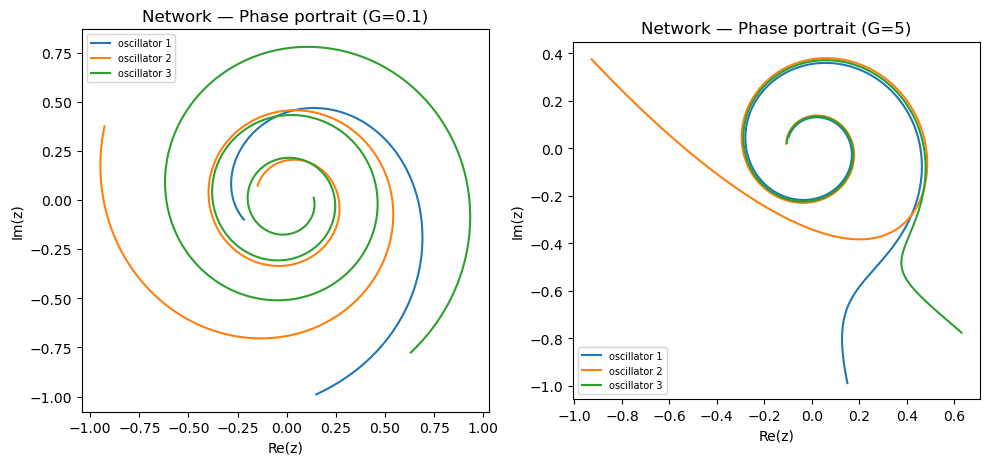

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for i in range(N):
    axes[0].plot(Z_weak[:, i].real, Z_weak[:, i].imag, label=f'oscillator {i+1}')
    axes[1].plot(Z_strong[:, i].real, Z_strong[:, i].imag, label=f'oscillator {i+1}')

for ax, title in zip(axes, ['Network — Phase portrait (G=0.1)', 'Network — Phase portrait (G=5)']):
    ax.set_xlabel('Re(z)'); ax.set_ylabel('Im(z)')
    ax.set_title(title)
    ax.set_aspect('equal')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()